# Clustering y Clasificacion

In [59]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn.objects as so
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## 1 - k medias a mano

In [2]:
x = [-1, 0, 1, 8/5, 2, 3, 4]
y = [2, 1, 2, 1, 1, 2, 1]

In [3]:
def distancia(p1, p2):
    x1, y1 = p1
    x2, y2 = p2
    return ((y2-y1)**2 + (x2-x1)**2)**0.5

In [4]:

# 1. Definimos los centros de los dos clusters
b1 = (-1,1)
b2 = (3, 2)

for _ in range(5):
    cluster_1 = []
    cluster_2 = []

    print(b1, b2)
    # 2. Calculo la distancia de cada punto a cada centro, y lo asigno al que tenga mas cerca
    for (x1, y1) in zip(x, y):
        dist_b1 = distancia(b1, (x1, y1))
        dist_b2 = distancia(b2, (x1, y1))
    
        if dist_b1 < dist_b2:
            cluster_1.append((x1, y1))
        else:
            cluster_2.append((x1, y1))
    
    # 3. Actualizo la ubicacion de los centros b1 y b2 calculando el valor medio de los puntos de cada uno
    b1 = (sum([a for (a, b) in cluster_1])/len(cluster_1), sum([b for (a, b) in cluster_1])/len(cluster_1))
    b2 = (sum([a for (a, b) in cluster_2])/len(cluster_2), sum([b for (a, b) in cluster_2])/len(cluster_2))

print(b1, b2)
print("Clusters")
print(cluster_1)
print(cluster_2)

(-1, 1) (3, 2)
(-0.5, 1.5) (2.32, 1.4)
(-0.5, 1.5) (2.32, 1.4)
(-0.5, 1.5) (2.32, 1.4)
(-0.5, 1.5) (2.32, 1.4)
(-0.5, 1.5) (2.32, 1.4)
Clusters
[(-1, 2), (0, 1)]
[(1, 2), (1.6, 1), (2, 1), (3, 2), (4, 1)]


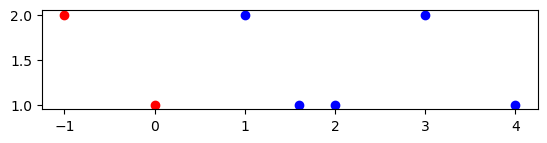

In [5]:
plt.scatter(*zip(*cluster_1), c="r")
plt.scatter(*zip(*cluster_2), c="b")
plt.gca().set_aspect('equal')

Es un poco dificil determinar los clusters en este ejemplo

## 2 - Datos artificialmente generados

In [6]:
data1 = pd.read_csv("p7-data1.csv")
data2 = pd.read_csv("p7-data2.csv")

In [7]:
data1.head()

,x,y
0,1.765881,-8.314427
1,6.483456,-3.332369
2,-8.480197,0.067655
3,4.706642,7.349470
4,4.502446,-8.135970


In [8]:
data2.head()

,x,y
0,9.319049,6.406236
1,2.752240,5.609928
2,8.469910,17.636237
3,8.701497,3.632456
4,7.858546,10.899268


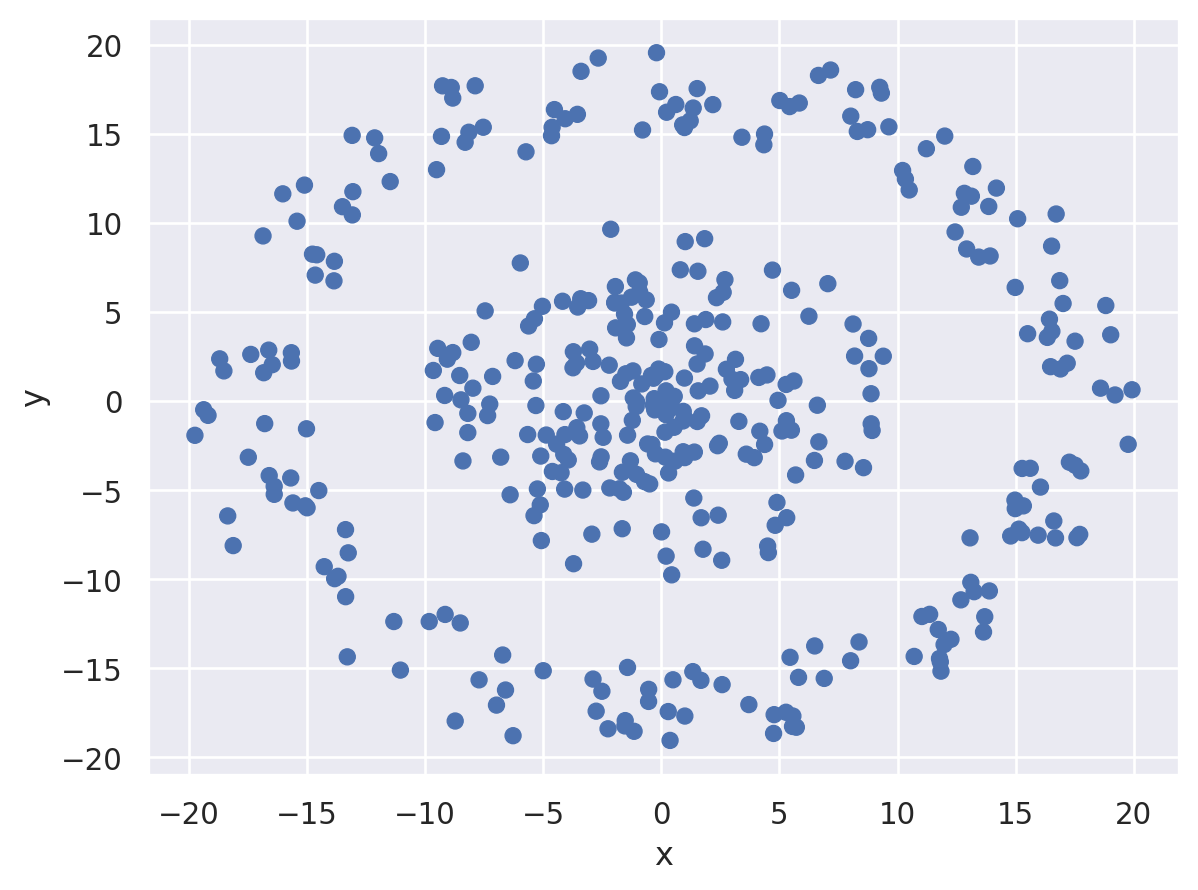

In [9]:
(
    so.Plot(data1, x="x", y="y")
    .add(so.Dot())
)

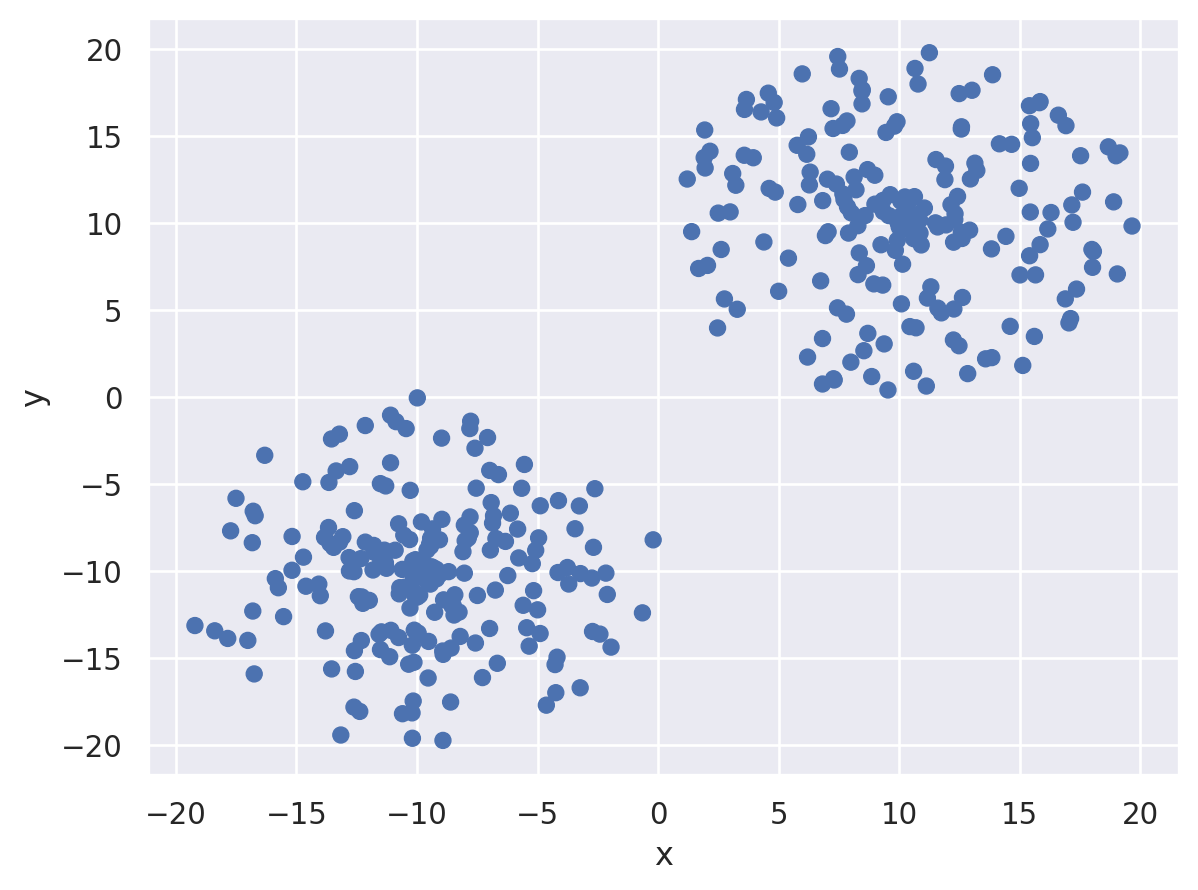

In [10]:
(
    so.Plot(data2, x="x", y="y")
    .add(so.Dot())
)

En cada dataset hay, aparentemente, dos clusters

In [11]:
kmeans_1 = KMeans(n_clusters=2)
kmeans_1.fit(data1)
kmeans_1.cluster_centers_

array([[10.20161559, -0.43728436],
       [-4.87241457,  0.34851628]])

In [12]:
kmeans_2 = KMeans(n_clusters=2)
kmeans_2.fit(data2)
kmeans_2.cluster_centers_

array([[ 10.1665714 ,  10.38192132],
       [ -9.64401457, -10.13471893]])

En el caso de data1, el metodo no funciona bien, ya que ambos clusters estan uno dentro de otro, y el metodo no los puede diferenciar

En el caso de data2, el resultado de cluster_centers_ es muy razonable al ver el grafico y la ubicacion de los centros de cada cluster

## 3 - Iris dataset

In [13]:
iris = pd.read_csv("p7-iris.txt", sep="\t")
iris.head()

,LongSepalo,AnchoSepalo,LongPetalo,AnchoPetalo
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


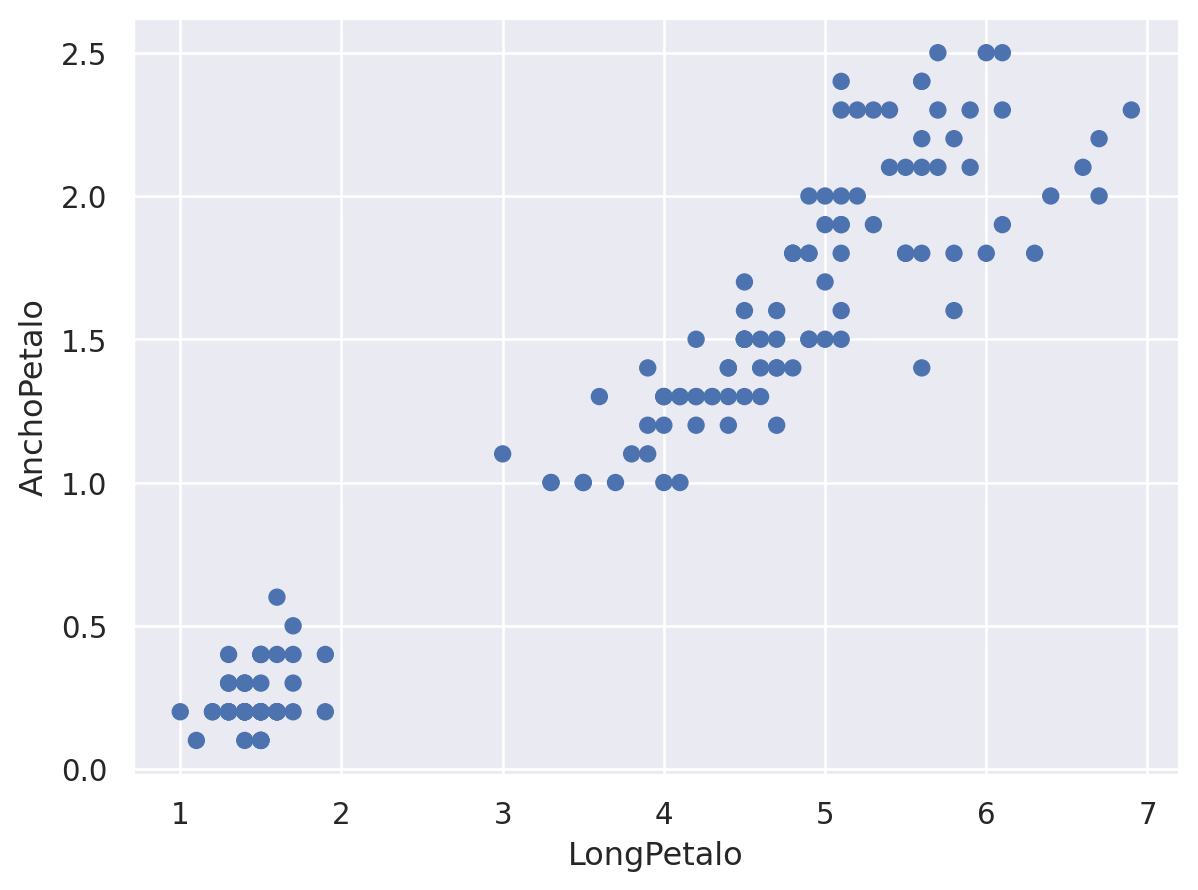

In [14]:
(
    so.Plot(iris, x="LongPetalo", y="AnchoPetalo")
    .add(so.Dot())
)

In [15]:
kmeans_iris = KMeans(n_clusters=3)
kmeans_iris.fit(iris)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [16]:
# Predicciones da un array de etiquetas para cada cluster
labels = kmeans_iris.predict(iris)
labels

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0], dtype=int32)

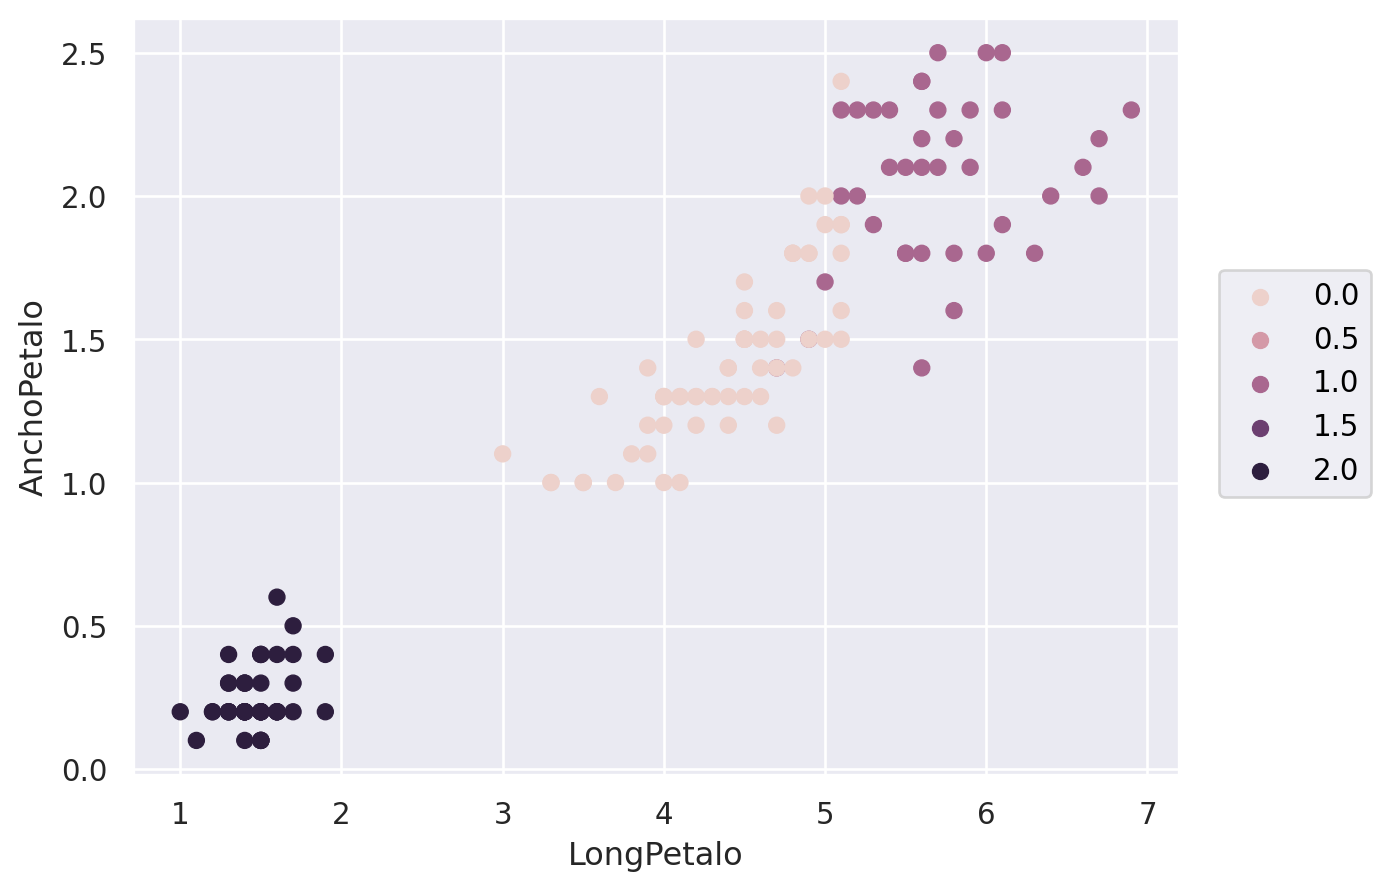

In [17]:
(
    so.Plot(iris, x="LongPetalo", y="AnchoPetalo", color=labels)
    .add(so.Dot())
)

In [18]:
def wcss(n_clusters: int):
    clusters = {}

    # Inicializo con lista vacia cada indice del cluster
    for cluster in range(n_clusters):
        clusters[cluster] = []

    # Recorro cada punto del dataset

In [19]:
kmeans_iris.inertia_

78.9450658259773

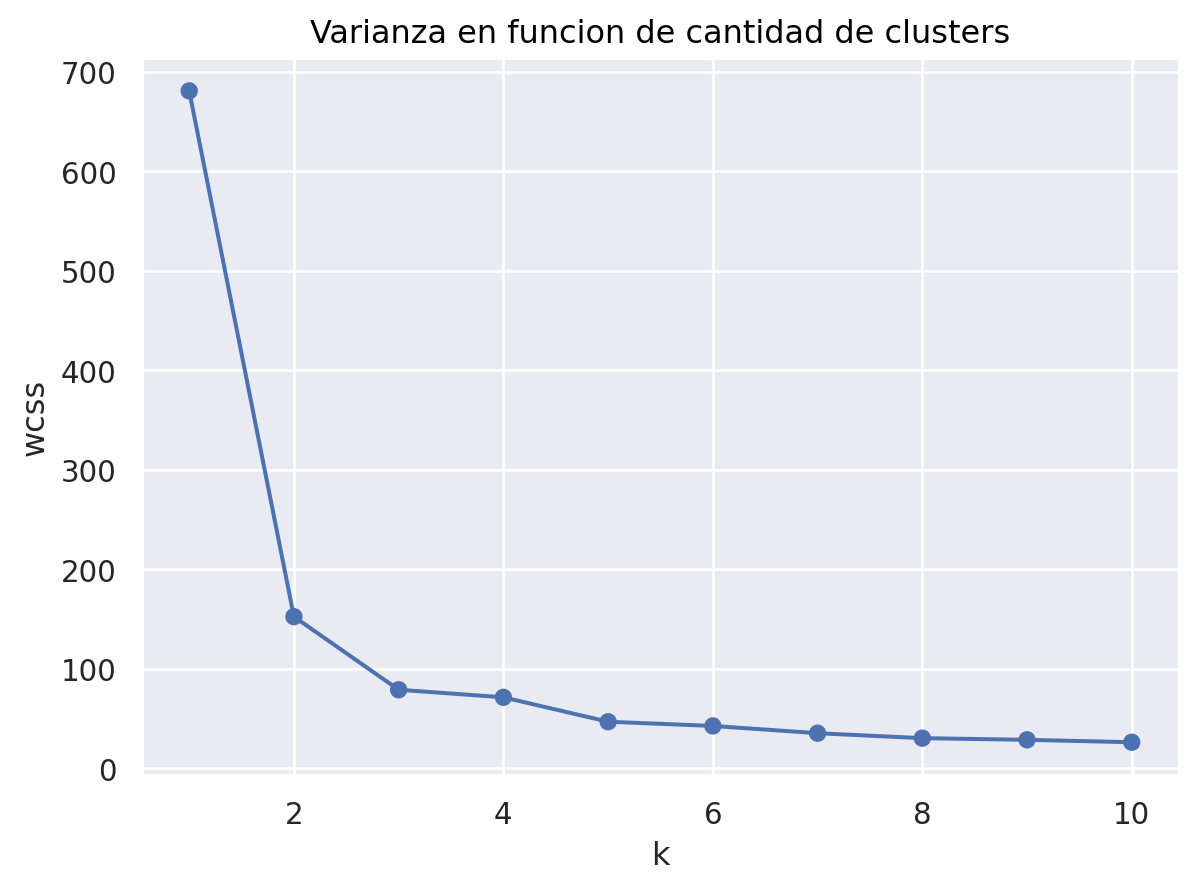

In [20]:
wcss_values = []

for k in range(1, 11):
    kmeans_iris_k = KMeans(n_clusters=k)
    kmeans_iris_k.fit(iris)
    wcss = kmeans_iris_k.inertia_
    wcss_values.append(wcss)

(
    so.Plot(None, x=range(1, 11), y=wcss_values)
    .add(so.Dot())
    .add(so.Line())
    .label(
        x="k",
        y="wcss",
        title="Varianza en funcion de cantidad de clusters"
    )
)

A partir del grafico, podemos ver que un valor razonable de *k* es 3 (metodo del codo o *elbow*)

## 6 - k-NN para predecir sexo de pinguinos

In [23]:
penguins = sns.load_dataset("penguins")
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [26]:
penguins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [30]:
# Tiro filas con nan
penguins.dropna(inplace=True)

<Axes: >

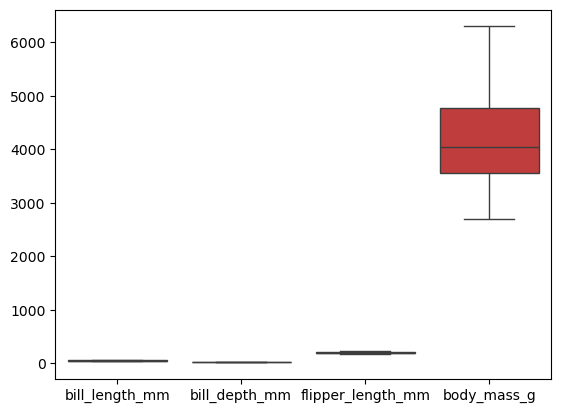

In [58]:
# Boxplots
sns.boxplot(data=penguins)

In [66]:
# Standard scaler
scaler = StandardScaler().set_output(transform="pandas")
num_cols = penguins.select_dtypes(include='number').columns
penguins[num_cols] = scaler.fit_transform(penguins[num_cols])

In [67]:
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,-0.896042,0.780732,-1.426752,-0.568475,Male
1,Adelie,Torgersen,-0.822788,0.119584,-1.069474,-0.506286,Female
2,Adelie,Torgersen,-0.676280,0.424729,-0.426373,-1.190361,Female
4,Adelie,Torgersen,-1.335566,1.085877,-0.569284,-0.941606,Female
5,Adelie,Torgersen,-0.859415,1.747026,-0.783651,-0.692852,Male


In [76]:
X = penguins[[
    "bill_length_mm", "flipper_length_mm"
    # "bill_length_mm", 
    # "bill_depth_mm",
    # "flipper_length_mm",
    # "body_mass_g"
]]
y = penguins["sex"]

In [77]:
# Separo en train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [78]:
scores = []
for k in range(1, 21, 2):
    knn_sex = KNeighborsClassifier(k)
    knn_sex.fit(X_train, y_train)
    scores.append(knn_sex.score(X_test, y_test))

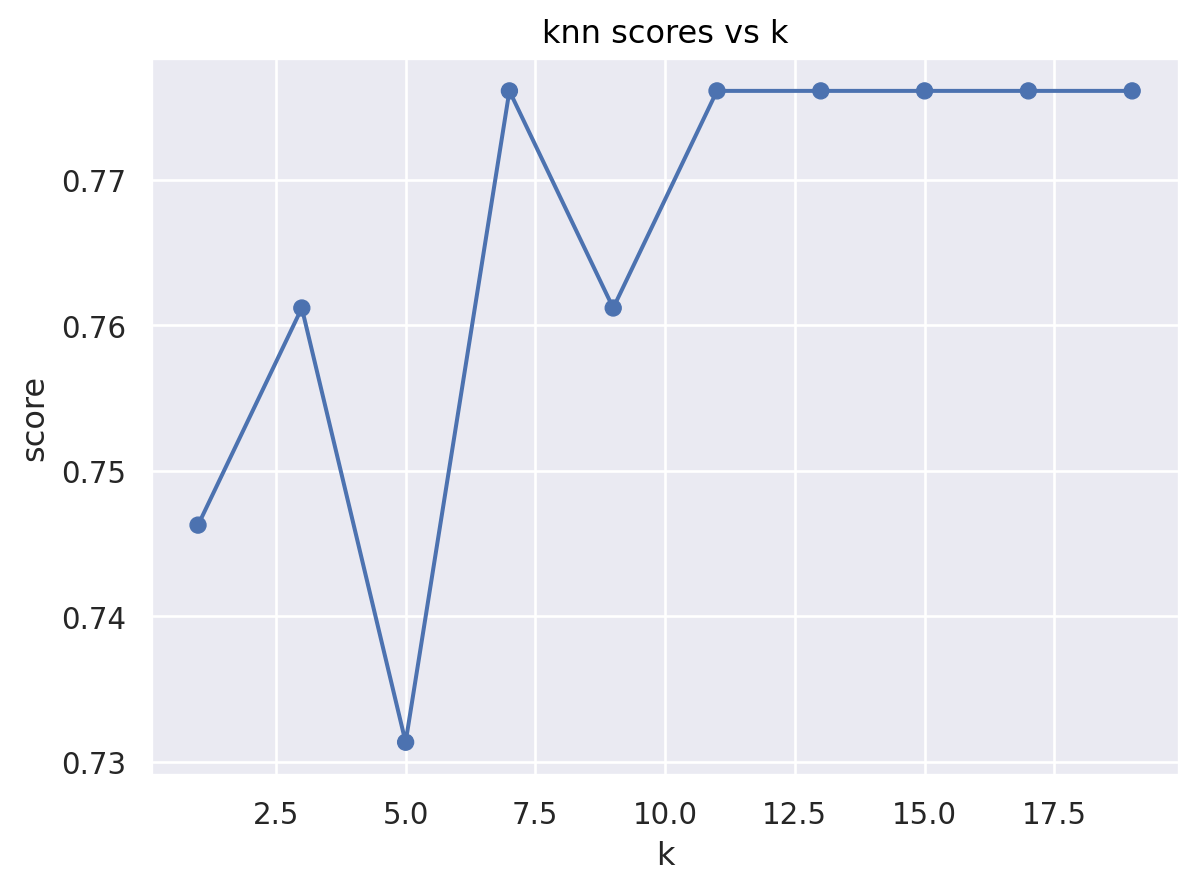

In [79]:
(
    so.Plot(None, x=range(1, 21, 2), y=scores)
    .add(so.Dot())
    .add(so.Line())
    .label(
        x="k",
        y="score",
        title="knn scores vs k"
    )
)

## 7 - k-NN para predecir especie de pinguinos

In [80]:
X = penguins[[
    "bill_length_mm", 
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]]
y = penguins["species"]

In [81]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [82]:
scores = []
for k in range(1, 21, 2):
    knn_sex = KNeighborsClassifier(k)
    knn_sex.fit(X_train, y_train)
    scores.append(knn_sex.score(X_test, y_test))

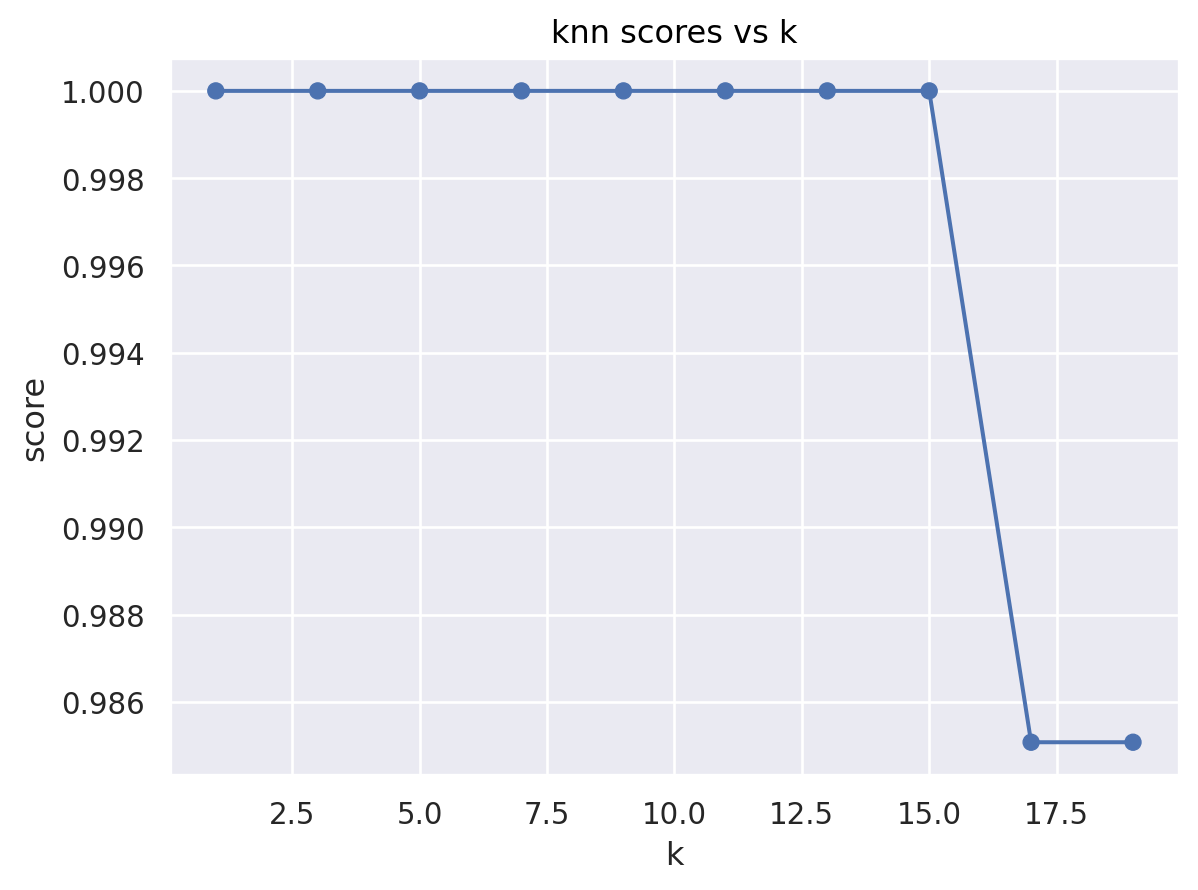

In [83]:
(
    so.Plot(None, x=range(1, 21, 2), y=scores)
    .add(so.Dot())
    .add(so.Line())
    .label(
        x="k",
        y="score",
        title="knn scores vs k"
    )
)